In [1]:
!pip install xgboost shap

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   -----------------

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import shap

In [3]:
df1 = pd.read_csv("Year_2009_2010_Cleaned.csv")
df2 = pd.read_csv("Year_2010_2011_Cleaned.csv")

df = pd.concat(
    [df1, df2],
    ignore_index=True
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,SalesAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Regular,Online,UPI,High,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Regular,Online,UPI,Low,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Premium,Offline,Card,Medium,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,New,Retail,Cash,Low,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Regular,Online,Net Banking,High,30.0


In [4]:
customer_data = (
    df.groupby("Customer ID")
      .agg(
          TotalOrders=("Invoice", "nunique"),
          TotalQuantity=("Quantity", "sum"),
          TotalSpending=("SalesAmount", "sum"),
          LastPurchase=("InvoiceDate", "max")
      )
      .reset_index()
)

customer_data.head()

,Customer ID,TotalOrders,TotalQuantity,TotalSpending,LastPurchase
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00
1,12347.0,8,3286,5633.32,2011-12-07 15:52:00
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00
4,12350.0,1,197,334.40,2011-02-02 16:01:00


In [5]:
today = df["InvoiceDate"].max()

customer_data["Recency"] = (
    today - customer_data["LastPurchase"]
).dt.days

In [6]:
customer_data["Churn"] = (
    customer_data["Recency"] > 90
).astype(int)

In [7]:
customer_data["Churn"].value_counts()

Churn
1    2987
0    2894
Name: count, dtype: int64

In [8]:
features = [
    "TotalOrders",
    "TotalQuantity",
    "TotalSpending",
    "Recency"
]

X = customer_data[features]

y = customer_data["Churn"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(accuracy, 2)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       568
           1       1.00      1.00      1.00       609

    accuracy                           1.00      1177
   macro avg       1.00      1.00      1.00      1177
weighted avg       1.00      1.00      1.00      1177



In [13]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_test
)

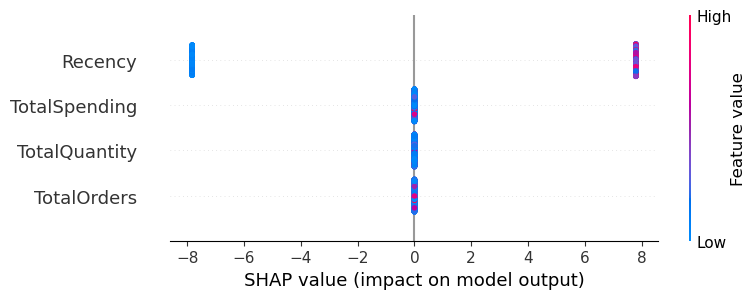

In [14]:
shap.summary_plot(
    shap_values,
    X_test
)

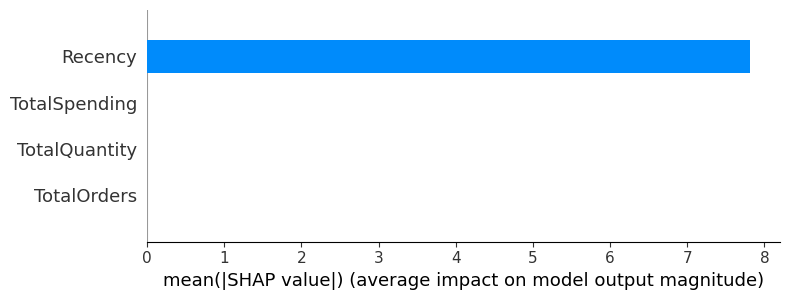

In [15]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [16]:
customer_data["ChurnPrediction"] = model.predict(
    customer_data[features]
)

In [17]:
customer_data["ChurnProbability"] = model.predict_proba(
    customer_data[features]
)[:, 1]

In [18]:
high_risk_customers = customer_data[
    customer_data["ChurnProbability"] > 0.7
]

high_risk_customers.head()

,Customer ID,TotalOrders,TotalQuantity,TotalSpending,LastPurchase,Recency,Churn,ChurnPrediction,ChurnProbability
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,1,1,0.9996
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,1,0.9996
5,12351.0,1,261,300.93,2010-11-29 15:23:00,374,1,1,0.9996
7,12353.0,2,212,406.76,2011-05-19 17:47:00,203,1,1,0.9996
8,12354.0,1,530,1079.40,2011-04-21 13:11:00,231,1,1,0.9996


In [19]:
customer_data.to_csv(
    "customer_churn_predictions.csv",
    index=False
)

print(
    "Churn predictions saved successfully."
)

Churn predictions saved successfully.
